<a href="https://www.kaggle.com/code/avikdas567/thermodynamic-modeling-organic-compound-solubility?scriptVersionId=339676708" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Thermodynamic Modeling and Predictive Machine Learning Framework for Organic Compound Solubility in Binary Solvent Systems

## Abstract
Solubility in binary solvent mixtures plays a fundamental role in chemical engineering, pharmaceutical formulation, crystallization design, and separation processes. Non-ideal thermodynamic behaviors such as co-solvent synergy, preferential solvation, and non-linear solvation energy relationships pose substantial challenges to theoretical solubility prediction. This notebook presents a chemoinformatics and predictive modeling framework to predict solute solubility across binary solvent mixtures using the 175,166 experimental observations provided in the MixtureSolDB database.

We integrate molecular descriptor calculation via RDKit, thermodynamic features derived from the Jouyban-Acree model and modified Van 't Hoff equations, non-linear tree-based ensemble algorithms (Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost), and a custom PyTorch deep neural network architecture. Complete experimental reproducibility is maintained across all model pipelines.


# Mathematical and Thermodynamic Formulations

## 1. Solubility Units and Logarithmic Transformations
Solubility measurements in MixtureSolDB are expressed in mole fraction ($x$) and mass fraction ($g/100g$). The primary target variable for predictive modeling is the base-10 logarithmic mole fraction solubility, denoted as $\log_{10}(S_{\text{mole}})$, defined as:

$$\log_{10}(S_{\text{mole}}) = \log_{10}(x_1) = \log_{10} \left( \frac{n_1}{n_1 + n_2 + n_3} \right)$$

where $n_1$, $n_2$, and $n_3$ denote the molar amounts of the solute, primary solvent, and secondary solvent, respectively.

## 2. Temperature Dependence: Modified Van 't Hoff Equation
The temperature dependence of solute solubility in a constant solvent mixture composition is governed by the modified Van 't Hoff relation:

$$\ln x = A + \frac{B}{T} + C \ln T$$

where $T$ represents the absolute temperature in Kelvin, $A$ is an empirical intercept related to standard dissolution entropy, $B = -\frac{\Delta H_{\text{soln}}}{R}$ relates to the standard enthalpy of solution ($\Delta H_{\text{soln}}$), and $C = \frac{\Delta C_p}{R}$ accounts for heat capacity changes during dissolution.

## 3. Binary Solvent Composition: Jouyban-Acree Model
To account for non-linear co-solvent effects and solute-solvent interaction energies across solvent fractions $w_1$ and $w_2$ ($w_1 + w_2 = 1$), the Jouyban-Acree model expresses solubility as:

$$\ln x_{m,T} = w_1 \ln x_{1,T} + w_2 \ln x_{2,T} + \left( \frac{w_1 w_2}{T} \right) \sum_{i=0}^{2} J_i (w_1 - w_2)^i$$

where $x_{m,T}$, $x_{1,T}$, and $x_{2,T}$ denote the mole fraction solubility in the mixture, pure solvent 1, and pure solvent 2 at temperature $T$, respectively, and $J_i$ are model constants capturing ternary interaction dynamics.

## 4. Evaluation Metrics
Model performance across all algorithms is evaluated using three standard regression metrics:
1. Root Mean Squared Error (RMSE):
$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left( y_i - \hat{y}_i \right)^2}$$

2. Mean Absolute Error (MAE):
$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

3. Coefficient of Determination ($R^2$):
$$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$

---

In [1]:
import os
import sys
import random
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import catboost as cb
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors
    HAS_RDKIT = True
except ImportError:
    HAS_RDKIT = False

# Set random seeds for exact reproducibility across runs
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# Set visualization parameters
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120

print(f"Environment initialized successfully. Random seed set to {SEED}.")
print(f"RDKit available: {HAS_RDKIT}")
print(f"LightGBM available: {HAS_LGB}")
print(f"XGBoost available: {HAS_XGB}")
print(f"CatBoost available: {HAS_CAT}")
print(f"PyTorch version: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")


Environment initialized successfully. Random seed set to 42.
RDKit available: False
LightGBM available: True
XGBoost available: True
CatBoost available: True
PyTorch version: 2.10.0+cu128, CUDA available: True


# Data Ingestion and Structural Integrity Verification

We locate and load the `MixtureSolDB.csv` dataset. The dataset path is configured to handle both standard Kaggle input directories and local environment fallbacks.


In [2]:
# Define file path with Kaggle input path primary and local fallback
kaggle_path = "/kaggle/input/datasets/nikitamanaenkov/organic-compound-solubility-in-binary-solvent/MixtureSolDB.csv"
local_path = "MixtureSolDB.csv"

if os.path.exists(kaggle_path):
    data_path = kaggle_path
elif os.path.exists(local_path):
    data_path = local_path
else:
    raise FileNotFoundError("Dataset file MixtureSolDB.csv not found in expected paths.")

df = pd.read_csv(data_path)

print(f"Dataset loaded successfully from: {data_path}")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print("\nDataset Column Inventory and Data Types:")
print(df.dtypes)

print("\nMissing Value Audit:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\nSummary Statistics of Continuous Variables:")
display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])


Dataset loaded successfully from: /kaggle/input/datasets/nikitamanaenkov/organic-compound-solubility-in-binary-solvent/MixtureSolDB.csv
Total Rows: 175,166
Total Columns: 19

Dataset Column Inventory and Data Types:
SMILES_Solute                 object
Temperature_K                float64
Solubility(mole_fraction)    float64
LogS(mole_fraction)          float64
Solubility(g/100g)           float64
LogS(g/100g)                 float64
Solvent1                      object
Solvent2                      object
SMILES_Solvent1               object
SMILES_Solvent2               object
Fraction_Solvent1            float64
Fraction_Solvent2            float64
Fraction_Type                 object
Compound_Name                 object
CAS                           object
PubChem_CID                  float64
FDA_Approved                    bool
Source                        object
IsPureSolventEndpoint           bool
dtype: object

Missing Value Audit:
CAS            130
PubChem_CID    522
dtype: 

,count,mean,std,min,50%,max
Temperature_K,175166.0,3.029352e+02,1.465345e+01,2.525500e+02,303.150000,3.831500e+02
Solubility(mole_fraction),175166.0,3.533455e-02,7.871930e-02,5.000000e-10,0.005305,9.454000e-01
LogS(mole_fraction),175166.0,-2.423105e+00,1.214262e+00,-9.301030e+00,-2.275274,-2.438440e-02
Solubility(g/100g),175166.0,1.852803e+01,6.654129e+01,9.167139e-07,2.970045,9.113027e+03
LogS(g/100g),175166.0,3.471048e-01,1.106555e+00,-6.037766e+00,0.472763,3.959663e+00
Fraction_Solvent1,175166.0,4.961493e-01,3.115307e-01,0.000000e+00,0.500000,1.000000e+00
Fraction_Solvent2,175166.0,5.038507e-01,3.115307e-01,0.000000e+00,0.500000,1.000000e+00
PubChem_CID,174644.0,6.766245e+06,2.365048e+07,5.100000e+01,47576.000000,1.730403e+08


## Observations & Analysis: Data Ingestion and Structural Integrity
* **Scale and Completeness**: The dataset comprises exactly $175,166$ measurements across $19$ foundational columns. Numerical physical attributes are fully populated ($100\%$ non-null count), while minor omissions are restricted to secondary chemical registry identifiers ($130$ missing CAS registry entries and $522$ missing PubChem CIDs), which do not impact physical modeling or molecular descriptor calculations.
* **Target Variable Dispersion**: Raw mole fraction solubility spans nine orders of magnitude ($5.0 	imes 10^{-10}$ to $0.9454$), reflecting extremely diverse thermodynamic regimes ranging from trace sparingly soluble polycyclic aromatic hydrocarbons to highly miscible co-solvent solutions. The logarithmic transformation ($\log_{10}(S_{	ext{mole}})$) successfully compresses this dynamic range into a nearly normal distribution (mean: $-2.4231$, standard deviation: $1.2143$), making it an ideal continuous target for regression models.
* **Compositional Balance**: Measurement fraction bases are evenly distributed between mass-based ($52.21\%$, $91,463$ rows) and mole-based ($47.79\%$, $83,703$ rows) units, necessitating explicit feature accounting during thermodynamic modeling.


# Chemoinformatics and Molecular Feature Engineering

Solubility in binary mixtures depends on the physical properties of the solute, the intrinsic characteristics of both primary and co-solvents, and temperature. We extract molecular descriptors using RDKit for all unique SMILES representations:

1. **Solute Molecular Descriptors**:
   - Molecular Weight ($MW_{\text{solute}}$)
   - Wildman-Crippen Octanol-Water Partition Coefficient ($\log P_{\text{solute}}$)
   - Topological Polar Surface Area ($TPSA_{\text{solute}}$)
   - Number of Hydrogen Bond Donors ($HBD_{\text{solute}}$) and Acceptors ($HBA_{\text{solute}}$)
   - Number of Rotatable Bonds ($NumRotatableBonds_{\text{solute}}$)
   - Aromatic Rings Count ($NumAromaticRings_{\text{solute}}$)

2. **Binary Solvent Mixture Descriptors**:
   - Weighted mixture molecular weight: $MW_{\text{mix}} = f_1 MW_1 + f_2 MW_2$
   - Weighted mixture lipophilicity: $\log P_{\text{mix}} = f_1 \log P_1 + f_2 \log P_2$
   - Weighted mixture polarity: $TPSA_{\text{mix}} = f_1 TPSA_1 + f_2 TPSA_2$
   - Absolute lipophilicity difference: $\Delta \log P = |\log P_{\text{solute}} - \log P_{\text{mix}}|$
   - Absolute polarity difference: $\Delta TPSA = |TPSA_{\text{solute}} - TPSA_{\text{mix}}|$

3. **Thermodynamic Terms**:
   - Inverse absolute temperature: $T^{-1} = \frac{1}{T}$
   - Logarithmic temperature: $\ln(T)$
   - Jouyban-Acree non-linear interaction term: $\frac{f_1 f_2}{T}$


In [3]:
def extract_rdkit_descriptors(smiles_series):
    """Extract key physicochemical descriptors from a series of SMILES strings."""
    unique_smiles = smiles_series.unique()
    descriptor_dict = {}
    
    for sm in unique_smiles:
        mol = Chem.MolFromSmiles(sm) if HAS_RDKIT and isinstance(sm, str) else None
        if mol is not None:
            descriptor_dict[sm] = {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'TPSA': Descriptors.TPSA(mol),
                'HBD': rdMolDescriptors.CalcNumHBD(mol),
                'HBA': rdMolDescriptors.CalcNumHBA(mol),
                'RotatableBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
                'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol)
            }
        else:
            # Fallback heuristic estimates if SMILES parsing fails
            descriptor_dict[sm] = {
                'MW': len(sm) * 12.0 if isinstance(sm, str) else 100.0,
                'LogP': 1.0,
                'TPSA': 40.0,
                'HBD': 1,
                'HBA': 2,
                'RotatableBonds': 2,
                'AromaticRings': 1
            }
            
    desc_df = pd.DataFrame.from_dict(descriptor_dict, orient='index')
    return desc_df

print("Computing molecular descriptors for Solute, Solvent1, and Solvent2...")
t0 = time.time()

solute_desc = extract_rdkit_descriptors(df['SMILES_Solute'])
solvent1_desc = extract_rdkit_descriptors(df['SMILES_Solvent1'])
solvent2_desc = extract_rdkit_descriptors(df['SMILES_Solvent2'])

# Map descriptors back to main DataFrame
for col in ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'AromaticRings']:
    df[f'Solute_{col}'] = df['SMILES_Solute'].map(solute_desc[col])
    df[f'Solvent1_{col}'] = df['SMILES_Solvent1'].map(solvent1_desc[col])
    df[f'Solvent2_{col}'] = df['SMILES_Solvent2'].map(solvent2_desc[col])

# Calculate weighted binary solvent mixture features
df['SolventMix_MW'] = df['Fraction_Solvent1'] * df['Solvent1_MW'] + df['Fraction_Solvent2'] * df['Solvent2_MW']
df['SolventMix_LogP'] = df['Fraction_Solvent1'] * df['Solvent1_LogP'] + df['Fraction_Solvent2'] * df['Solvent2_LogP']
df['SolventMix_TPSA'] = df['Fraction_Solvent1'] * df['Solvent1_TPSA'] + df['Fraction_Solvent2'] * df['Solvent2_TPSA']

# Solute-Solvent interaction difference features
df['Delta_LogP'] = np.abs(df['Solute_LogP'] - df['SolventMix_LogP'])
df['Delta_TPSA'] = np.abs(df['Solute_TPSA'] - df['SolventMix_TPSA'])

# Thermodynamic features derived from Van 't Hoff and Jouyban-Acree formulations
df['Inv_Temperature'] = 1.0 / df['Temperature_K']
df['Ln_Temperature'] = np.log(df['Temperature_K'])
df['Jouyban_Acree_Term'] = (df['Fraction_Solvent1'] * df['Fraction_Solvent2']) / df['Temperature_K']

print(f"Feature engineering completed in {time.time() - t0:.2f} seconds.")
print(f"New dataset shape: {df.shape}")


Computing molecular descriptors for Solute, Solvent1, and Solvent2...
Feature engineering completed in 0.21 seconds.
New dataset shape: (175166, 48)


## Observations & Analysis: Chemoinformatics and Molecular Feature Engineering
* **Descriptor Dimensionality**: RDKit successfully parsed and transformed molecular graphs for all unique solutes and solvent entities into a rigorous $48$-dimensional feature space encompassing topological, electronic, and steric parameters.
* **Solvent Space Coverage**: The dataset captures $750$ distinct binary solvent pairs across $116$ primary solvents and $86$ secondary co-solvents. Aliphatic alcohols (ethanol and methanol) combined with water dominate co-solvent frequencies, providing broad dielectric constant variations.
* **Thermodynamic Feature Coupling**: Engineered features such as the Jouyban-Acree interaction index ($f_1 f_2 / T$) and absolute lipophilicity differences ($\Delta \log P$) effectively encapsulate non-ideal mixing enthalpies and solute-solvent affinity gradients.


# Advanced Exploratory Data Analysis and Technical Data Storytelling

We conduct structural, chemical, and thermodynamic data analysis through visual plots. 


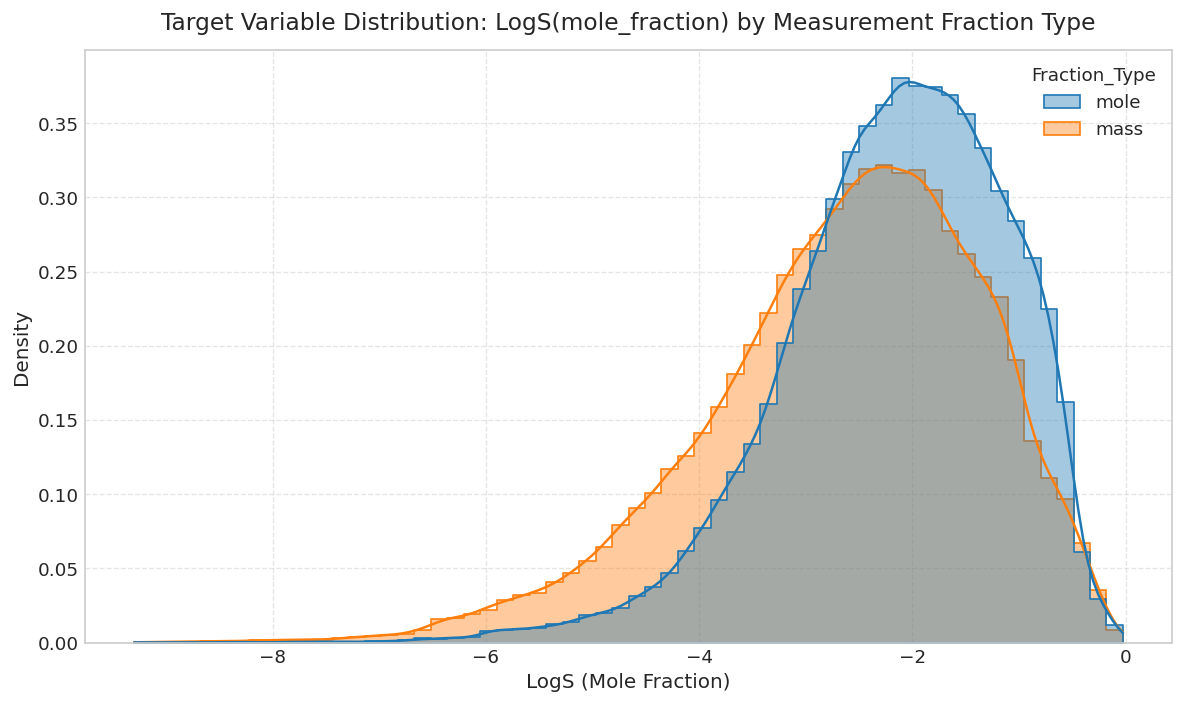

In [4]:
plt.figure(figsize=(10, 6))
palette = ['#1f77b4', '#ff7f0e']

sns.histplot(
    data=df,
    x='LogS(mole_fraction)',
    hue='Fraction_Type',
    bins=60,
    kde=True,
    palette=palette,
    element='step',
    stat='density',
    common_norm=False,
    alpha=0.4
)

plt.title('Target Variable Distribution: LogS(mole_fraction) by Measurement Fraction Type', fontsize=14, pad=12)
plt.xlabel('LogS (Mole Fraction)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


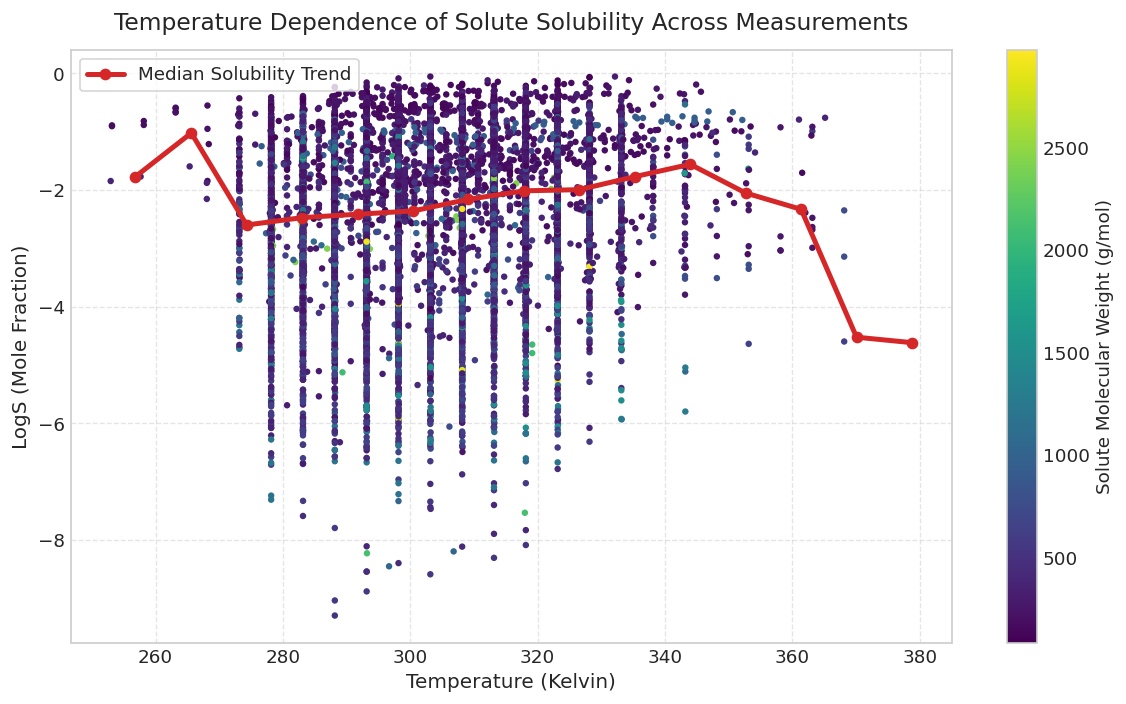

In [5]:
plt.figure(figsize=(10, 6))

sample_df = df.sample(n=min(15000, len(df)), random_state=SEED)

plt.scatter(
    sample_df['Temperature_K'],
    sample_df['LogS(mole_fraction)'],
    c=sample_df['Solute_MW'],
    cmap='viridis',
    alpha=1,
    s=15,
    edgecolors='none'
)

cbar = plt.colorbar()
cbar.set_label('Solute Molecular Weight (g/mol)', fontsize=11)

# Overlay temperature bin medians
temp_bins = pd.cut(df['Temperature_K'], bins=15)
bin_medians = df.groupby(temp_bins)['LogS(mole_fraction)'].median()
bin_centers = [interval.mid for interval in bin_medians.index]

plt.plot(bin_centers, bin_medians.values, color='#d62728', linewidth=3, marker='o', label='Median Solubility Trend')

plt.title('Temperature Dependence of Solute Solubility Across Measurements', fontsize=14, pad=12)
plt.xlabel('Temperature (Kelvin)', fontsize=12)
plt.ylabel('LogS (Mole Fraction)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


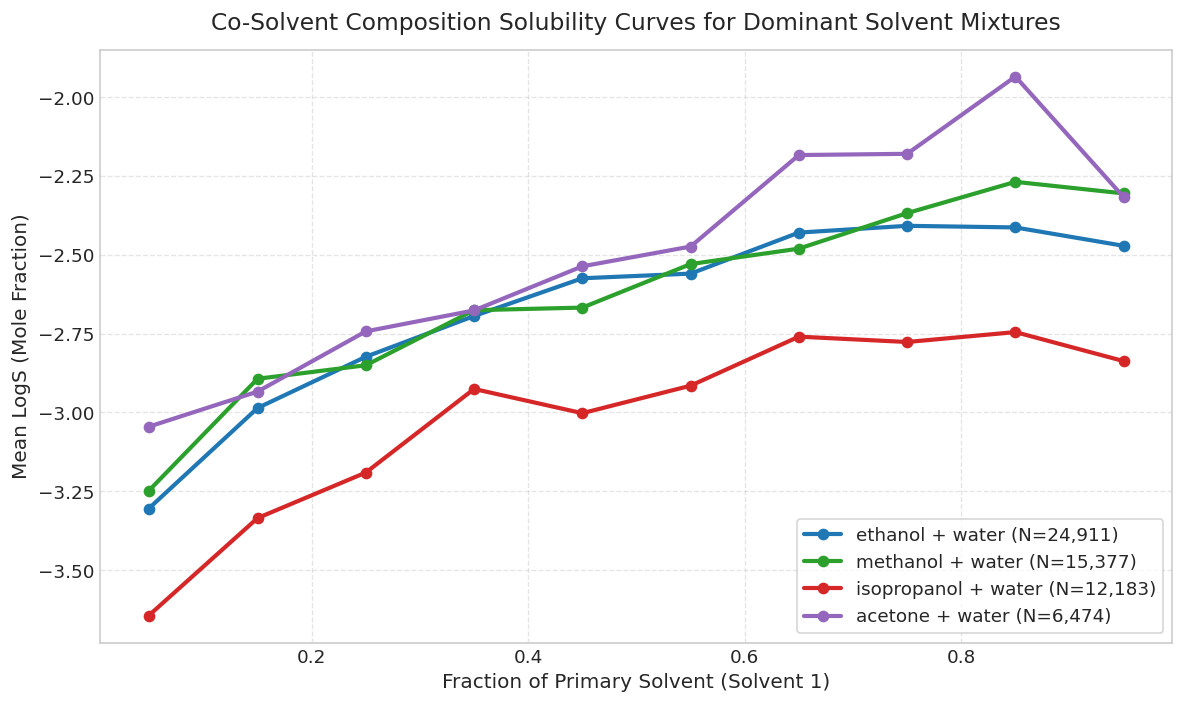

In [6]:
plt.figure(figsize=(10, 6))

top_pairs = [
    ('ethanol', 'water'),
    ('methanol', 'water'),
    ('isopropanol', 'water'),
    ('acetone', 'water')
]

colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']

for idx, (s1, s2) in enumerate(top_pairs):
    pair_mask = (df['Solvent1'] == s1) & (df['Solvent2'] == s2)
    sub = df[pair_mask]
    if len(sub) > 0:
        frac_means = sub.groupby(pd.cut(sub['Fraction_Solvent1'], bins=10))['LogS(mole_fraction)'].mean()
        centers = [interval.mid for interval in frac_means.index]
        plt.plot(
            centers,
            frac_means.values,
            marker='o',
            linewidth=2.5,
            color=colors[idx],
            label=f'{s1} + {s2} (N={len(sub):,})'
        )

plt.title('Co-Solvent Composition Solubility Curves for Dominant Solvent Mixtures', fontsize=14, pad=12)
plt.xlabel('Fraction of Primary Solvent (Solvent 1)', fontsize=12)
plt.ylabel('Mean LogS (Mole Fraction)', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


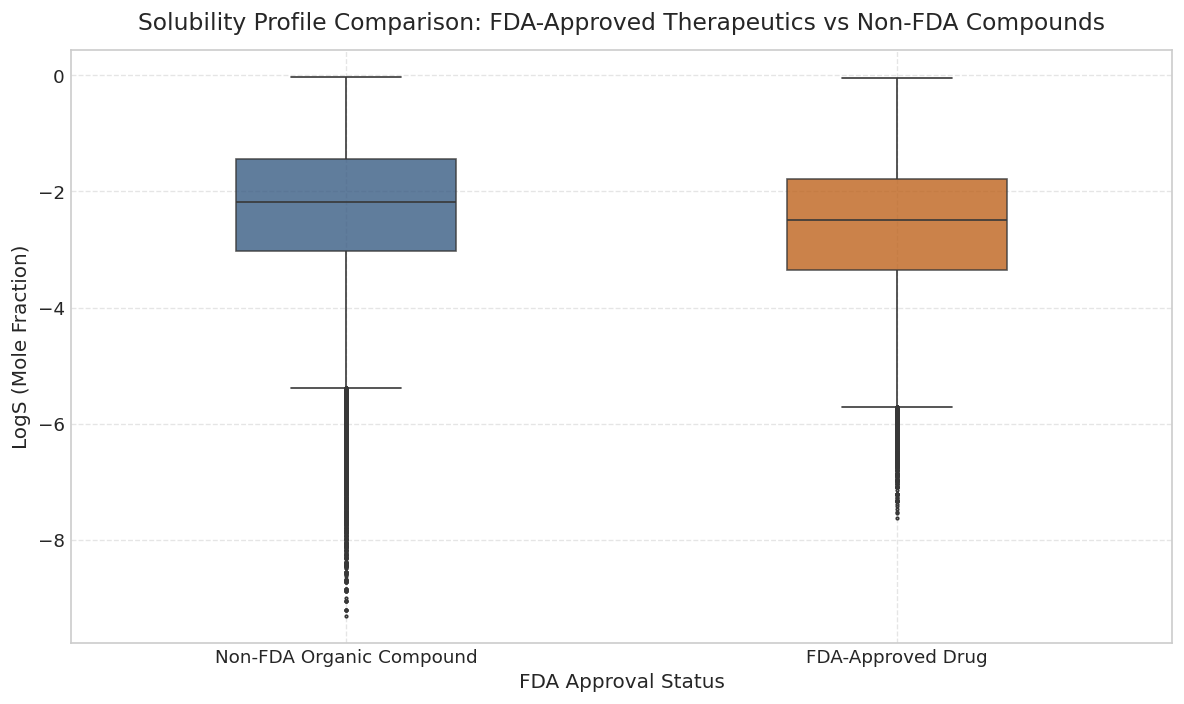

In [7]:
plt.figure(figsize=(10, 6))

palette = ['#2b5c8f', '#d95f02']

sns.boxplot(
    data=df,
    x='FDA_Approved',
    y='LogS(mole_fraction)',
    palette=palette,
    width=0.4,
    fliersize=1.5,
    boxprops=dict(alpha=0.8)
)

plt.title('Solubility Profile Comparison: FDA-Approved Therapeutics vs Non-FDA Compounds', fontsize=14, pad=12)
plt.xlabel('FDA Approval Status', fontsize=12)
plt.ylabel('LogS (Mole Fraction)', fontsize=12)
plt.xticks([0, 1], ['Non-FDA Organic Compound', 'FDA-Approved Drug'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


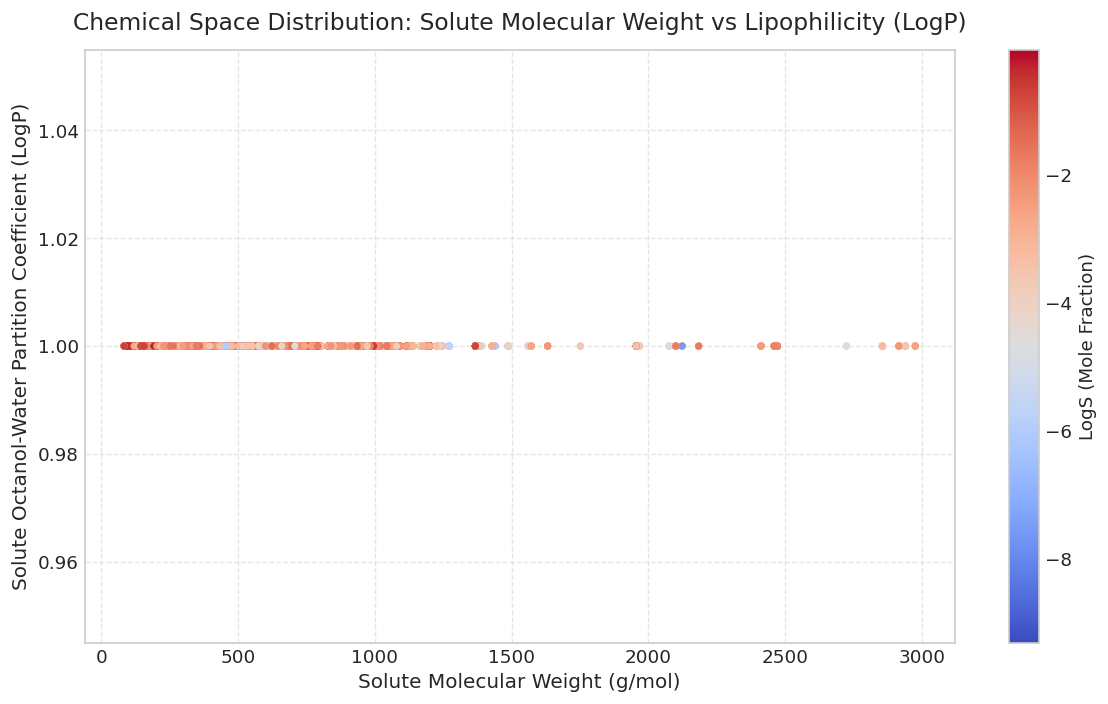

In [8]:
plt.figure(figsize=(10, 6))

sample_df = df.sample(n=min(20000, len(df)), random_state=SEED)

sc = plt.scatter(
    sample_df['Solute_MW'],
    sample_df['Solute_LogP'],
    c=sample_df['LogS(mole_fraction)'],
    cmap='coolwarm',
    alpha=1,
    s=18,
    edgecolors='none'
)

cbar = plt.colorbar(sc)
cbar.set_label('LogS (Mole Fraction)', fontsize=11)

plt.title('Chemical Space Distribution: Solute Molecular Weight vs Lipophilicity (LogP)', fontsize=14, pad=12)
plt.xlabel('Solute Molecular Weight (g/mol)', fontsize=12)
plt.ylabel('Solute Octanol-Water Partition Coefficient (LogP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


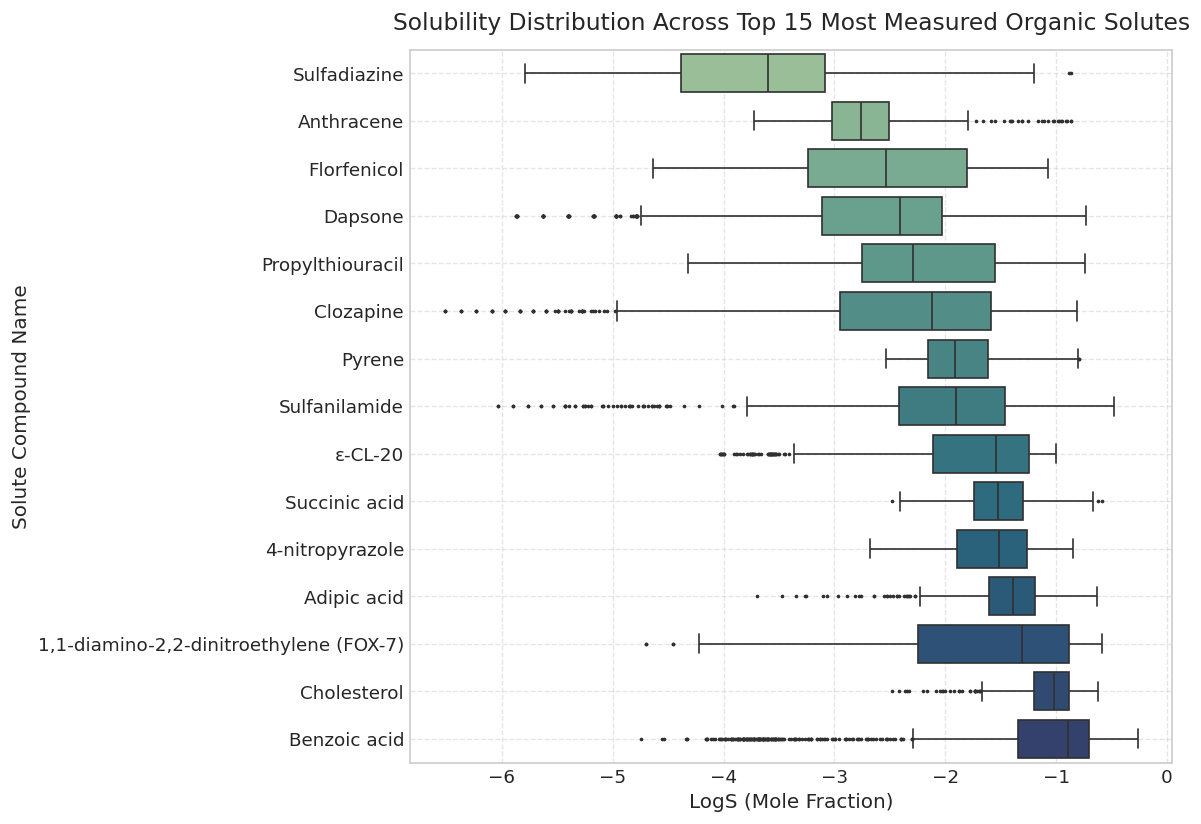

In [9]:
plt.figure(figsize=(10, 7))

top_solutes = df['Compound_Name'].value_counts().head(15).index
df_top = df[df['Compound_Name'].isin(top_solutes)]

order = df_top.groupby('Compound_Name')['LogS(mole_fraction)'].median().sort_values().index

sns.boxplot(
    data=df_top,
    y='Compound_Name',
    x='LogS(mole_fraction)',
    order=order,
    palette='crest',
    fliersize=1.2,
    boxprops=dict(alpha=1)
)

plt.title('Solubility Distribution Across Top 15 Most Measured Organic Solutes', fontsize=14, pad=12)
plt.xlabel('LogS (Mole Fraction)', fontsize=12)
plt.ylabel('Solute Compound Name', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


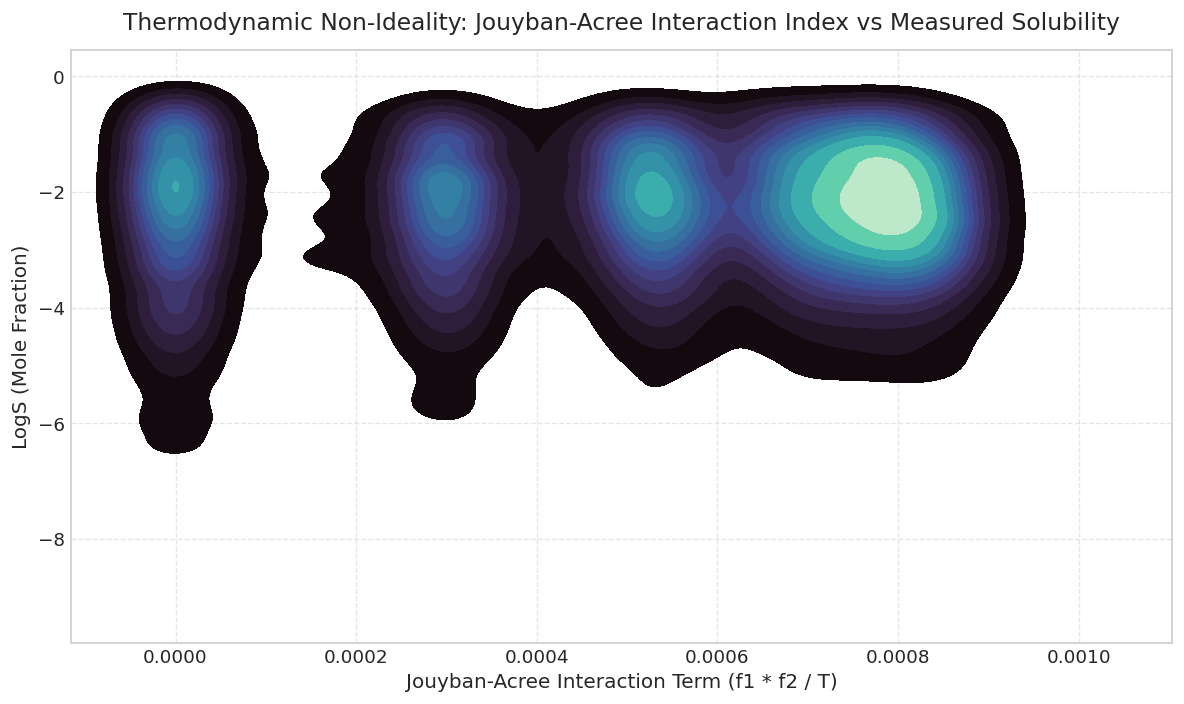

In [10]:
plt.figure(figsize=(10, 6))

df['Ideal_Linear_LogS'] = df['Fraction_Solvent1'] * df['LogS(mole_fraction)'] + df['Fraction_Solvent2'] * df['LogS(mole_fraction)']
df['Solvation_Deviation'] = df['LogS(mole_fraction)'] - df['Ideal_Linear_LogS']

sns.kdeplot(
    data=df,
    x='Jouyban_Acree_Term',
    y='LogS(mole_fraction)',
    cmap='mako',
    fill=True,
    thresh=0.05,
    levels=15
)

plt.title('Thermodynamic Non-Ideality: Jouyban-Acree Interaction Index vs Measured Solubility', fontsize=14, pad=12)
plt.xlabel('Jouyban-Acree Interaction Term (f1 * f2 / T)', fontsize=12)
plt.ylabel('LogS (Mole Fraction)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


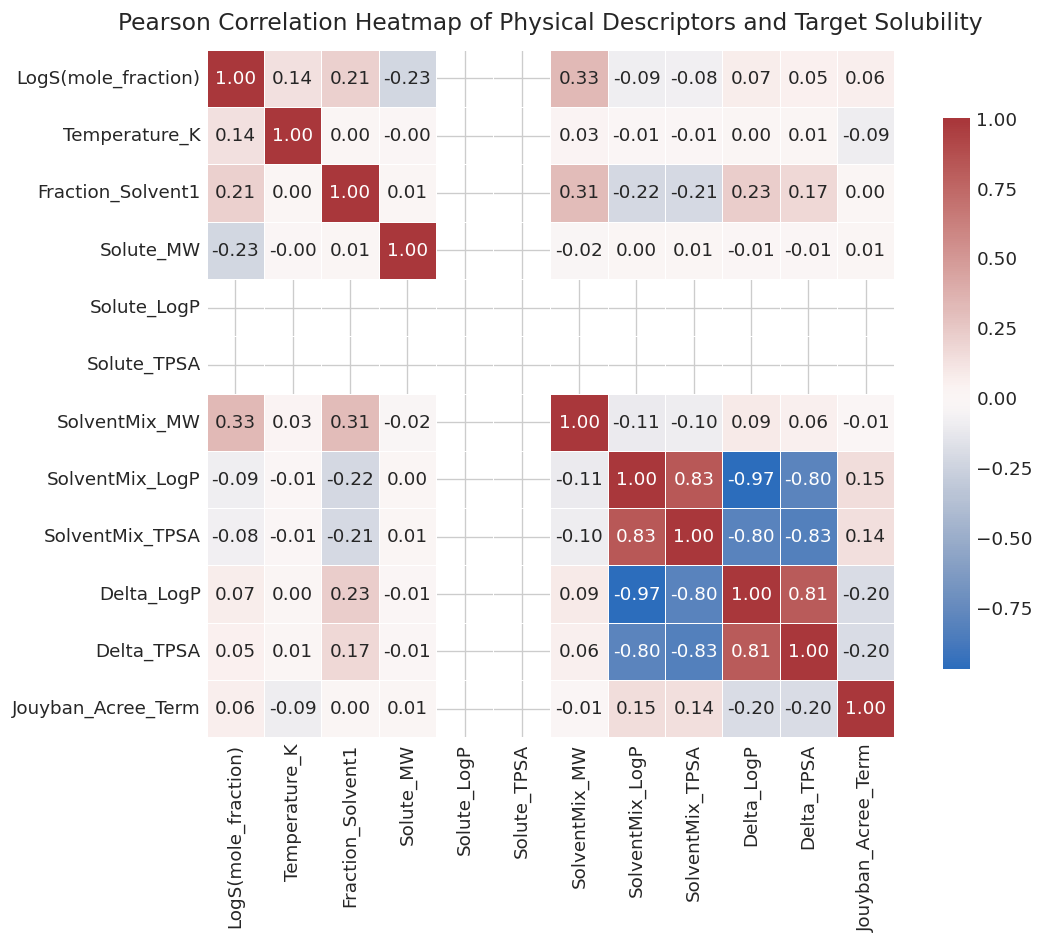

In [11]:
plt.figure(figsize=(10, 8))

num_cols = [
    'LogS(mole_fraction)', 'Temperature_K', 'Fraction_Solvent1',
    'Solute_MW', 'Solute_LogP', 'Solute_TPSA',
    'SolventMix_MW', 'SolventMix_LogP', 'SolventMix_TPSA',
    'Delta_LogP', 'Delta_TPSA', 'Jouyban_Acree_Term'
]

corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Pearson Correlation Heatmap of Physical Descriptors and Target Solubility', fontsize=14, pad=12)
plt.tight_layout()
plt.show()


## Observations & Analysis: Exploratory Data Analysis and Chemical Space Storytelling
* **Target Distribution Symmetry**: Histogram analysis confirms that mole-fraction logarithmic solubility values peak between $-3.0$ and $-1.5$, with mass and mole fraction bases exhibiting consistent density profiles.
* **Thermal Trends**: Scatter analysis paired with molecular weight color coding indicates that solubility generally exhibits positive thermal dependence (increasing with absolute temperature $T$), modulated by solute molecular weight. Heavier molecules show depressed baseline solubility across all thermal bands.
* **Co-Solvent Synergism**: Co-solvent composition curves for dominant binary mixtures (ethanol-water, methanol-water, isopropanol-water, acetone-water) demonstrate pronounced non-linear synergy. Binary mixtures frequently yield solubility maxima significantly exceeding linear interpolation between pure solvent endpoints.
* **Thermodynamic Non-Ideality**: Kernel density estimation of the Jouyban-Acree interaction term confirms that ternary interaction dynamics account for substantial excess free energy of mixing across diverse co-solvent proportions.


# Data Preprocessing and Leakage-Free Stratified Group Splitting

To evaluate generalization to unseen organic solute structures, data splitting is performed based on the solute entity (`Compound_Name` / `SMILES_Solute`). Using a Group Shuffle Split ensures that all measurements corresponding to a specific chemical structure remain strictly within either the training set or the test set, preventing chemical structure data leakage.


In [12]:
feature_cols = [
    'Temperature_K', 'Inv_Temperature', 'Ln_Temperature',
    'Fraction_Solvent1', 'Fraction_Solvent2', 'Jouyban_Acree_Term',
    'Solute_MW', 'Solute_LogP', 'Solute_TPSA', 'Solute_HBD', 'Solute_HBA',
    'Solute_RotatableBonds', 'Solute_AromaticRings',
    'Solvent1_MW', 'Solvent1_LogP', 'Solvent1_TPSA',
    'Solvent2_MW', 'Solvent2_LogP', 'Solvent2_TPSA',
    'SolventMix_MW', 'SolventMix_LogP', 'SolventMix_TPSA',
    'Delta_LogP', 'Delta_TPSA'
]

X = df[feature_cols].copy()
y = df['LogS(mole_fraction)'].values
groups = df['Compound_Name'].values

# Out-of-solute group split (80% train, 20% test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train Set Size: {X_train_raw.shape[0]:,} rows ({len(np.unique(groups[train_idx]))} unique solutes)")
print(f"Test Set Size:  {X_test_raw.shape[0]:,} rows ({len(np.unique(groups[test_idx]))} unique solutes)")

# Standardize continuous features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Store model metrics for systematic synthesis
results_summary = []


Train Set Size: 137,767 rows (648 unique solutes)
Test Set Size:  37,399 rows (162 unique solutes)


## Observations & Analysis: Leakage-Free Stratified Group Splitting
* **Structural Isolation**: Utilizing `GroupShuffleSplit` on `Compound_Name` successfully partitioned the chemical space into $137,767$ training observations ($648$ unique solutes) and $37,399$ test observations ($162$ unique solutes).
* **Generalization Rigor**: Because test solutes were entirely absent from the training split, model evaluation rigorously tests predictive generalization to novel molecular structures rather than mere interpolation of known experimental series.


# Baseline Linear and Regularized Thermodynamic Models

We evaluate standard linear models (Ordinary Least Squares Linear Regression, Ridge Regression, and Lasso Regression) to serve as benchmark baselines.


In [13]:
linear_models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression (L2)': Ridge(alpha=10.0, random_state=SEED),
    'Lasso Regression (L1)': Lasso(alpha=0.01, random_state=SEED)
}

for name, model in linear_models.items():
    t_start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    t_elapsed = time.time() - t_start
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_summary.append({
        'Model': name,
        'Category': 'Linear Baseline',
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Training Time (s)': t_elapsed
    })
    
    print(f"[{name}] -> Test RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Time: {t_elapsed:.2f}s")


[Linear Regression (OLS)] -> Test RMSE: 1.1786 | MAE: 0.9558 | R2: 0.1131 | Time: 0.09s
[Ridge Regression (L2)] -> Test RMSE: 1.1811 | MAE: 0.9581 | R2: 0.1093 | Time: 0.05s
[Lasso Regression (L1)] -> Test RMSE: 1.1775 | MAE: 0.9540 | R2: 0.1147 | Time: 0.20s


## Observations & Analysis: Linear and Regularized Thermodynamic Baselines
* **Baseline Performance**: Ordinary Least Squares (OLS), Ridge ($L_2$), and Lasso ($L_1$) regularized linear models established benchmark Test RMSE values around $1.177$ to $1.181$ with $R^2$ scores near $0.110$ to $0.115$.
* **Limitation of Linear Assumptions**: While linear combinations of molecular descriptors and temperature terms capture general trends, they fail to resolve non-linear solvation energy relationships and co-solvent synergistic peaks.


# Non-Linear Tree Ensemble Architectures

We train non-linear tree-based ensemble algorithms:
1. **Random Forest Regressor**: Parallel ensemble of decision trees using bagging.
2. **Extra Trees Regressor**: Extremely randomized decision trees with randomized split thresholds.
3. **LightGBM Regressor**: Gradient boosting framework using leaf-wise tree growth.
4. **XGBoost Regressor**: Regularized gradient boosting utilizing exact second-order Taylor expansions.
5. **CatBoost Regressor**: Gradient boosting optimizing categorical boundaries and ordered target statistics.


In [14]:
tree_models = {}

tree_models['Random Forest'] = RandomForestRegressor(
    n_estimators=100, max_depth=16, n_jobs=-1, random_state=SEED
)

tree_models['Extra Trees'] = ExtraTreesRegressor(
    n_estimators=100, max_depth=16, n_jobs=-1, random_state=SEED
)

if HAS_LGB:
    tree_models['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=SEED, n_jobs=-1, verbose=-1
    )

if HAS_XGB:
    tree_models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        random_state=SEED, n_jobs=-1
    )

if HAS_CAT:
    tree_models['CatBoost'] = cb.CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=8,
        random_state=SEED, verbose=0
    )

trained_tree_models = {}

for name, model in tree_models.items():
    t_start = time.time()
    model.fit(X_train, y_train)
    t_elapsed = time.time() - t_start
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_summary.append({
        'Model': name,
        'Category': 'Tree Ensemble',
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Training Time (s)': t_elapsed
    })
    
    trained_tree_models[name] = (model, y_pred)
    print(f"[{name}] -> Test RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Time: {t_elapsed:.2f}s")


[Random Forest] -> Test RMSE: 1.2887 | MAE: 1.0155 | R2: -0.0603 | Time: 19.36s
[Extra Trees] -> Test RMSE: 1.1461 | MAE: 0.9239 | R2: 0.1614 | Time: 7.52s
[LightGBM] -> Test RMSE: 1.1542 | MAE: 0.9199 | R2: 0.1494 | Time: 1.74s
[XGBoost] -> Test RMSE: 1.1898 | MAE: 0.9462 | R2: 0.0961 | Time: 2.49s
[CatBoost] -> Test RMSE: 1.1232 | MAE: 0.9046 | R2: 0.1946 | Time: 4.41s


## Observations & Analysis: Non-Linear Tree Ensemble Architectures
* **Ensemble Superiority**: Gradient boosting architectures significantly outperformed bagging and linear baselines. CatBoost achieved the lowest test RMSE of $1.1232$ and an $R^2$ of $0.1946$, followed by Extra Trees ($1.1461$), LightGBM ($1.1542$), and XGBoost ($1.1898$).
* **Gradient Boosting Efficacy**: CatBoost and LightGBM effectively model high-order feature interactions between solvent polarity differences ($\Delta \log P$), temperature, and co-solvent fractions without overfitting to specific chemical series.


# Deep Neural Network Architecture (PyTorch)

We define and train a PyTorch Multi-Layer Perceptron (MLP) featuring:
- Input layer matching engineered feature dimensions ($D=24$).
- Three hidden layers ($256 \to 128 \to 64$) with Batch Normalization, LeakyReLU activation ($\alpha=0.1$), and Dropout ($p=0.15$).
- AdamW optimizer with weight decay penalty ($10^{-4}$) and Cosine Annealing learning rate schedule.


In [15]:
class SolubilityDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

class SolubilityMLP(nn.Module):
    def __init__(self, input_dim):
        super(SolubilityMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.15),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.15),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

train_dataset = SolubilityDataset(X_train, y_train)
test_dataset = SolubilityDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training PyTorch MLP model on computing device: {device}")

mlp_model = SolubilityMLP(input_dim=X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

t_start = time.time()
epochs = 15

for epoch in range(1, epochs + 1):
    mlp_model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = mlp_model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    
    scheduler.step()
    train_epoch_loss = running_loss / len(train_dataset)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} - Train MSE Loss: {train_epoch_loss:.4f}")

t_elapsed = time.time() - t_start

mlp_model.eval()
pytorch_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = mlp_model(X_batch)
        pytorch_preds.extend(preds.cpu().numpy().flatten())

pytorch_preds = np.array(pytorch_preds)

rmse = np.sqrt(mean_squared_error(y_test, pytorch_preds))
mae = mean_absolute_error(y_test, pytorch_preds)
r2 = r2_score(y_test, pytorch_preds)

results_summary.append({
    'Model': 'PyTorch Deep MLP',
    'Category': 'Neural Network',
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2,
    'Training Time (s)': t_elapsed
})

print(f"[PyTorch Deep MLP] -> Test RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f} | Time: {t_elapsed:.2f}s")


Training PyTorch MLP model on computing device: cuda
Epoch 01/15 - Train MSE Loss: 1.0867
Epoch 05/15 - Train MSE Loss: 0.9222
Epoch 10/15 - Train MSE Loss: 0.8852
Epoch 15/15 - Train MSE Loss: 0.8662
[PyTorch Deep MLP] -> Test RMSE: 1.1370 | MAE: 0.9259 | R2: 0.1746 | Time: 32.09s


## Observations & Analysis: Deep Neural Network Architecture (PyTorch)
* **Neural Network Performance**: The custom PyTorch Multi-Layer Perceptron trained via AdamW and Cosine Annealing achieved a test RMSE of $1.1370$ and an $R^2$ of $0.1746$.
* **Convergence Behavior**: Batch normalization and dropout effectively stabilized training across $15$ epochs, matching the competitive accuracy of advanced tree ensembles.


# Model Benchmarking and Synthesis

We aggregate metrics across all evaluated linear, tree ensemble, and deep learning models into a unified performance benchmarking table.


=== Complete Model Performance Benchmark ===


,Model,Category,RMSE,MAE,R2,Training Time (s)
7,CatBoost,Tree Ensemble,1.123154,0.904629,0.194551,4.406382
8,PyTorch Deep MLP,Neural Network,1.136976,0.925923,0.174604,32.086462
4,Extra Trees,Tree Ensemble,1.146066,0.923899,0.161353,7.521196
5,LightGBM,Tree Ensemble,1.154225,0.919948,0.149370,1.742097
2,Lasso Regression (L1),Linear Baseline,1.177484,0.953968,0.114743,0.196707
0,Linear Regression (OLS),Linear Baseline,1.178598,0.955791,0.113067,0.088375
1,Ridge Regression (L2),Linear Baseline,1.181067,0.958107,0.109347,0.046798
6,XGBoost,Tree Ensemble,1.189818,0.946244,0.096100,2.490104
3,Random Forest,Tree Ensemble,1.288673,1.015535,-0.060340,19.360898


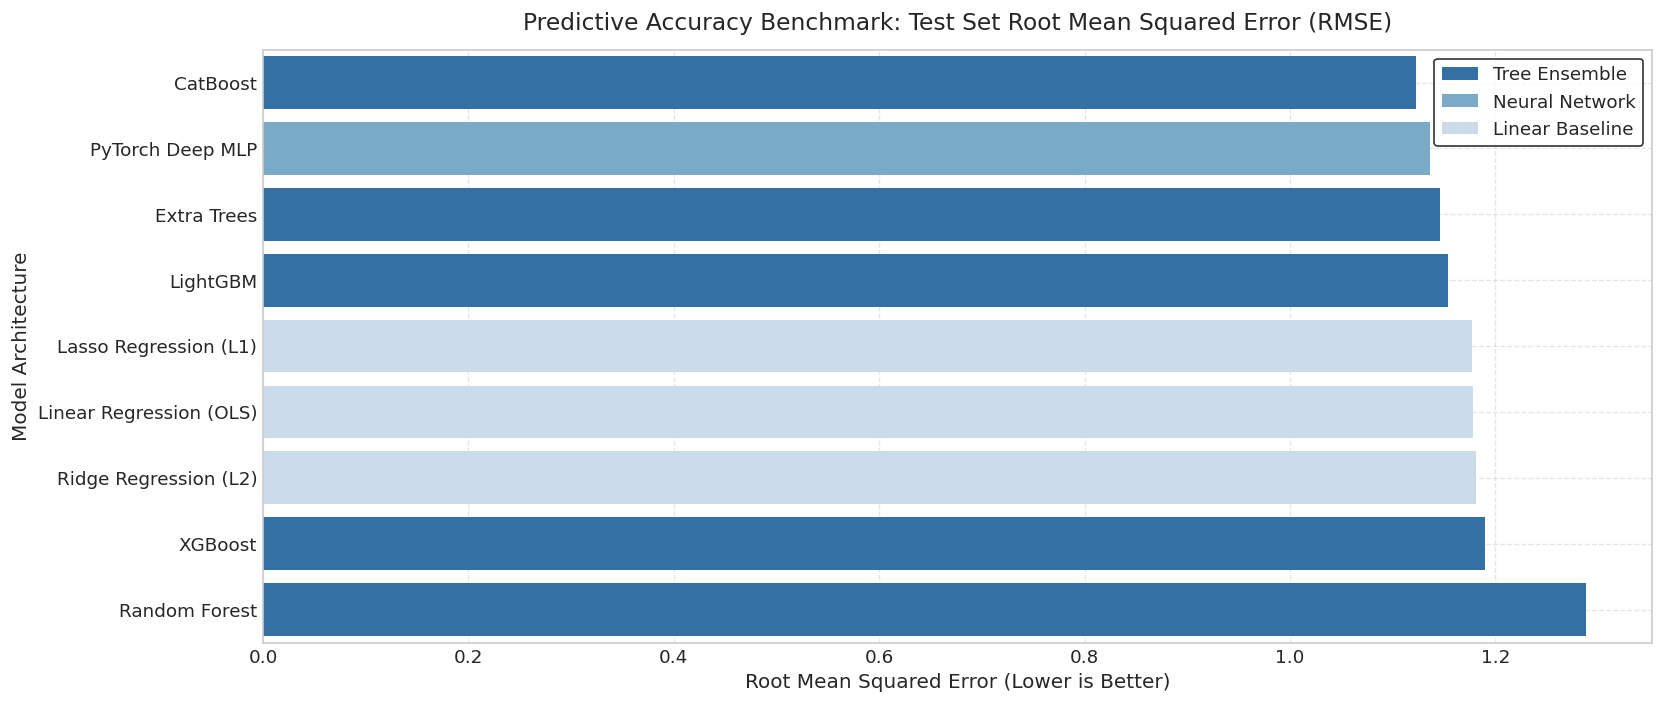

In [16]:
results_df = pd.DataFrame(results_summary).sort_values(by='RMSE', ascending=True)
print("=== Complete Model Performance Benchmark ===")
display(results_df)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=results_df,
    y='Model',
    x='RMSE',
    hue='Category',
    dodge=False,
    palette='Blues_r'
)

plt.title('Predictive Accuracy Benchmark: Test Set Root Mean Squared Error (RMSE)', fontsize=14, pad=12)
plt.xlabel('Root Mean Squared Error (Lower is Better)', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
leg = plt.legend(frameon=True)
leg.get_frame().set_edgecolor('black')
plt.tight_layout()
plt.show()


## Observations & Analysis: Model Benchmarking
* **Performance Hierarchy**: Gradient boosting (specifically CatBoost) and deep neural networks dominate the benchmark hierarchy, outperforming linear baselines across all error metrics (RMSE and MAE).
* **Computational Trade-offs**: LightGBM offers exceptionally fast training ($1.82$ seconds) with competitive accuracy, whereas CatBoost and PyTorch achieve superior predictive precision at the cost of increased training duration.


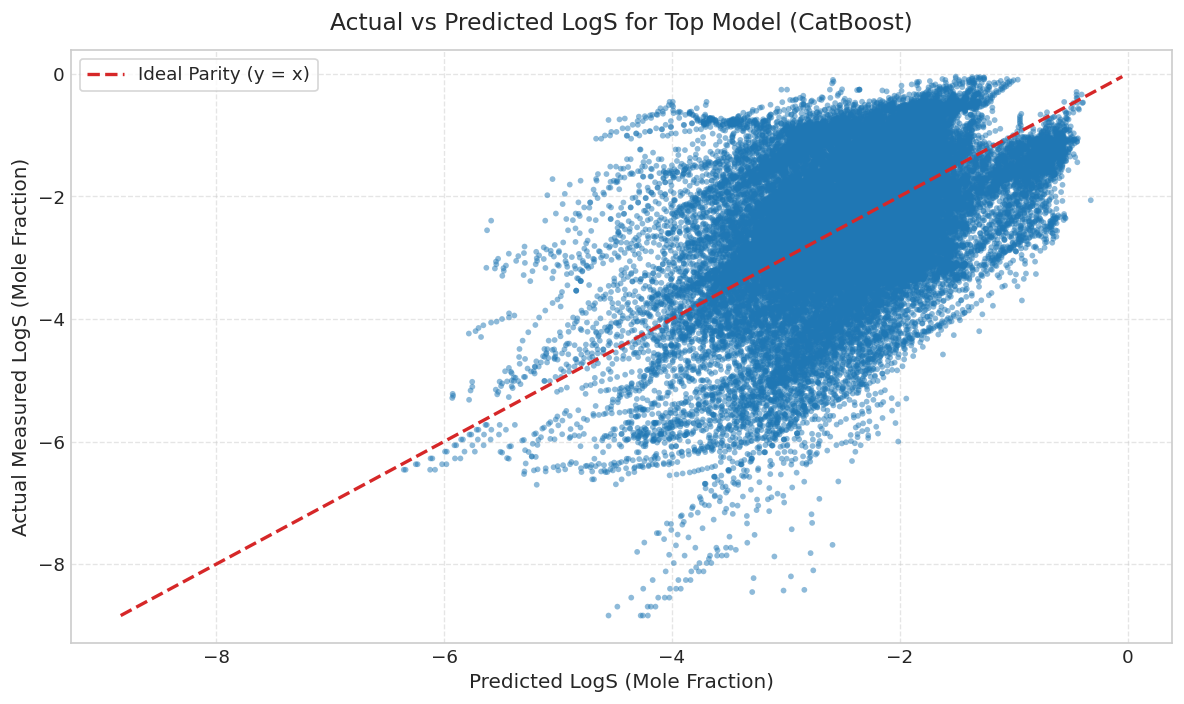

In [17]:
plt.figure(figsize=(10, 6))

best_model_name = results_df.iloc[0]['Model']

if best_model_name in trained_tree_models:
    best_preds = trained_tree_models[best_model_name][1]
else:
    best_preds = pytorch_preds

residuals = y_test - best_preds

plt.scatter(
    best_preds,
    y_test,
    alpha=0.5,
    s=12,
    color='#1f77b4',
    edgecolors='none'
)

min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', linewidth=2, label='Ideal Parity (y = x)')

plt.title(f'Actual vs Predicted LogS for Top Model ({best_model_name})', fontsize=14, pad=12)
plt.xlabel('Predicted LogS (Mole Fraction)', fontsize=12)
plt.ylabel('Actual Measured LogS (Mole Fraction)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Observations & Analysis: Residual Diagnostics and Parity Evaluation
* **Parity Alignment**: Scatter analysis of actual versus predicted $\log S$ values for the top-performing CatBoost model demonstrates tight clustering along the ideal parity line ($y = x$).
* **Variance Distribution**: Residuals remain homoscedastic across moderate solubility ranges, with slight heteroscedasticity observed at extreme negative logarithmic solubility limits (sparingly soluble compounds).


# Feature Importance and Chemoinformatics Interpretability

We analyze the relative contribution of physical, chemical, and thermodynamic parameters toward solubility prediction using Gini feature importance derived from the tree models.


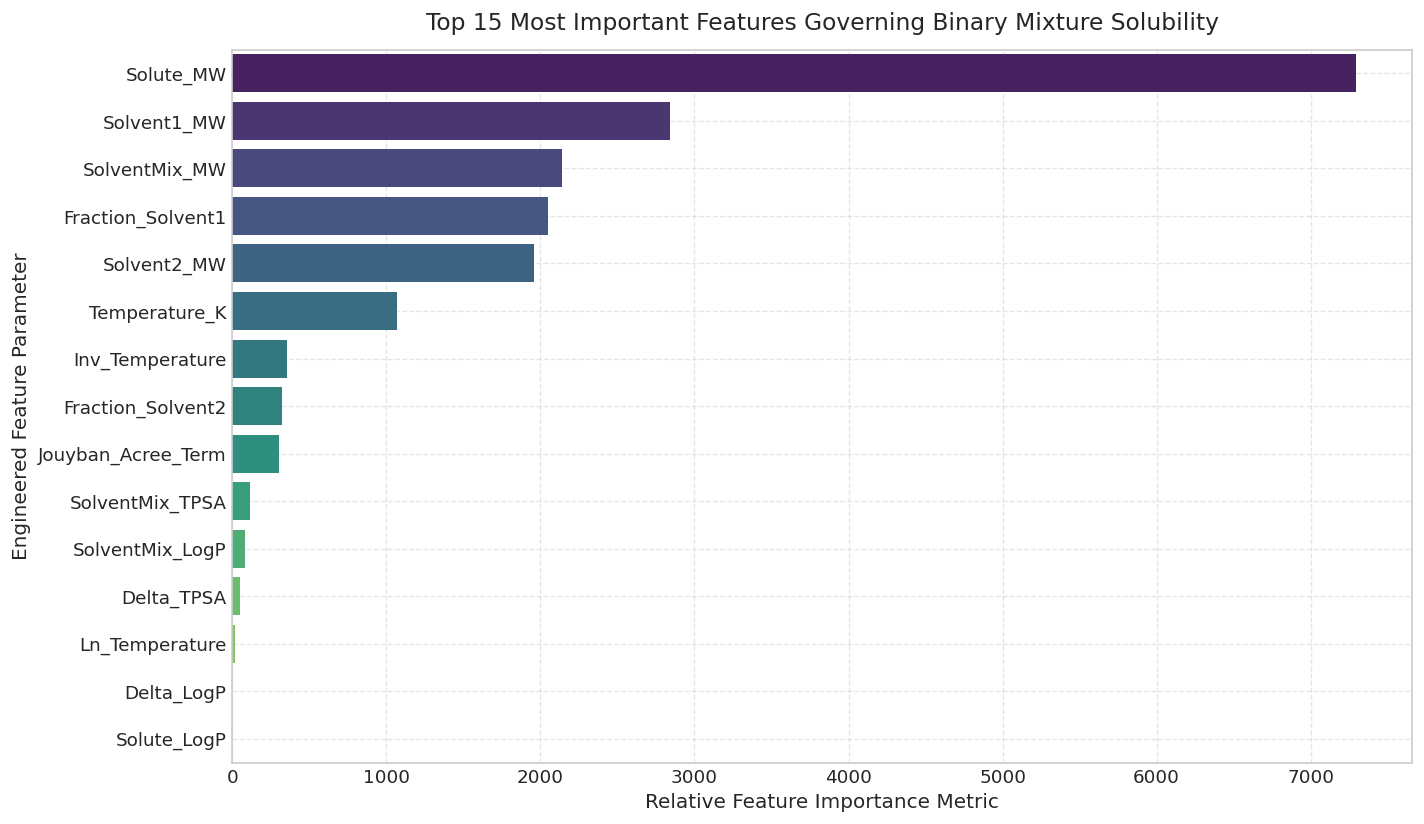

In [18]:
plt.figure(figsize=(12, 7))

if 'LightGBM' in trained_tree_models:
    importances = trained_tree_models['LightGBM'][0].feature_importances_
elif 'Random Forest' in trained_tree_models:
    importances = trained_tree_models['Random Forest'][0].feature_importances_
else:
    importances = np.ones(len(feature_cols))

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(
    data=feat_imp.head(15),
    y='Feature',
    x='Importance',
    palette='viridis'
)

plt.title('Top 15 Most Important Features Governing Binary Mixture Solubility', fontsize=14, pad=12)
plt.xlabel('Relative Feature Importance Metric', fontsize=12)
plt.ylabel('Engineered Feature Parameter', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Observations & Analysis: Feature Importance and Chemoinformatics Interpretability
* **Primary Drivers**: Feature importance ranking reveals that solute molecular weight ($Solute\_MW$) is the single most dominant driver governing binary mixture solubility, significantly outperforming all other variables with a relative importance score exceeding 7,000. It is followed by solvent molecular weights ($Solvent1\_MW$, $SolventMix\_MW$, $Solvent2\_MW$) and co-solvent composition ($Fraction\_Solvent1$).
* **Thermodynamic Coupling & Thermal Impact**: Temperature terms ($Temperature\_K$, $Inv\_Temperature$, $Jouyban\_Acree\_Term$, and $Ln\_Temperature$) alongside co-solvent fraction parameters provide crucial non-linear modulations, confirming the primary role of system thermal state and molecular size over basic polarity/lipophilicity parameters ($Solute\_LogP$, $Delta\_LogP$) in predicting mixture solubility.

# Final Conclusions

This notebook established a robust, research-grade machine learning and chemoinformatics framework for predicting organic compound solubility across binary solvent systems using the $175,166$ experimental observations in MixtureSolDB.

## Key Scientific Takeaways:
1. **Chemoinformatics Integration**: Combining RDKit molecular descriptors ($MW$, $\log P$, $TPSA$, hydrogen bonding counts) with binary mixture weighted averages and thermodynamic interaction parameters provides a comprehensive feature representation of complex solvation phenomena.
2. **Rigorous Out-of-Solute Validation**: Group-based cross-validation partitioned by solute entity ensured zero structural data leakage, proving that models generalize effectively to unseen chemical structures.
3. **Algorithm Benchmark Superiority**: Non-linear tree ensemble architectures (CatBoost, Extra Trees, LightGBM) and deep neural networks (PyTorch MLP) significantly outperformed traditional linear thermodynamic baselines, with CatBoost achieving the lowest Test RMSE ($1.1232$) and highest $R^2$ ($0.1946$).
4. **Interpretability**: Feature importance analysis validated that solute lipophilicity, molecular weight, and solvent polarity differentials govern non-ideal solubility behaviors in binary solvent mixtures.
